In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print('GPU:', tf.config.list_physical_devices('GPU'))

TRAIN_DIR = '/content/dataset/train/'
VALID_DIR = '/content/dataset/valid/'
TEST_DIR  = '/content/dataset/test/'

IMG_SIZE   = (128, 128)
BATCH_SIZE = 64
EPOCHS     = 20


Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import shutil
import os

base = '/content/drive/MyDrive/Aerial Object Classification & Detection/'

if not os.path.exists('/content/dataset/train'):
    shutil.copytree(base + 'train-20260409T091319Z-3-001/train/', '/content/dataset/train')

    shutil.copytree(base + 'valid-20260409T091319Z-3-001/valid/', '/content/dataset/valid')

    shutil.copytree(base + 'test-20260409T091319Z-3-001/test/', '/content/dataset/test')
else:
    print(' Dataset already in local storage!')

# Verify
for split in ['train', 'valid', 'test']:
    for cls in ['bird', 'drone']:
        count = len(os.listdir(f'/content/dataset/{split}/{cls}'))
        print(f'{split}/{cls}: {count} images')

train/bird: 1414 images
train/drone: 1248 images
valid/bird: 217 images
valid/drone: 225 images
test/bird: 126 images
test/drone: 94 images


## Data Generators with Augmentation

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training - with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1)

# Validation & Test - only normalization
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=True)

val_gen = val_test_datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

print(f'Class Indices: {train_gen.class_indices}')

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 220 images belonging to 2 classes.
Class Indices: {'bird': 0, 'drone': 1}


## Building Custom CNN Model

In [4]:
from tensorflow.keras import layers, models

def build_custom_cnn():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        # Output
        layers.Dense(1, activation='sigmoid')])
    return model

cnn_model = build_custom_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,265 (32.36 MB)

 Trainable params: 8,482,817 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Compile Model

In [5]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

os.makedirs('/content/drive/MyDrive/Aerial Object Classification & Detection/models/', exist_ok=True)
save_path = '/content/drive/MyDrive/Aerial Object Classification & Detection/models/custom_cnn_best.h5'

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(save_path, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]
print(f'Model will save to: {save_path}')

Model will save to: /content/drive/MyDrive/Aerial Object Classification & Detection/models/custom_cnn_best.h5


##Train Custom CNN

In [7]:
history = cnn_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1)


Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.6084 - loss: 4.3758 - precision: 0.5803 - recall: 0.5854
Epoch 1: val_accuracy improved from None to 0.64027, saving model to /content/drive/MyDrive/Aerial Object Classification & Detection/models/custom_cnn_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Aerial Object Classification & Detection/models/custom_cnn_best.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6292 - loss: 2.6546 - precision: 0.6060 - recall: 0.5978 - val_accuracy: 0.6403 - val_loss: 5.2518 - val_precision: 0.9459 - val_recall: 0.3111 - learning_rate: 0.0010
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.6784 - loss: 0.6268 - precision: 0.6911 - recall: 0.5785
Epoch 2: val_accuracy did not improve from 0.64027
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 464ms/step - accuracy: 0.6871 - loss: 0.6108 - precision: 0.7017 - recall: 0.5785 - val_accuracy: 0.4842 - val_loss: 5.8960 - val_precision: 0.4286 - val_recall: 0.0400 - learning_rate: 0.0010
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.7235 - loss: 0.5451 - precision: 0.7647 - recall: 0.6117
Epoch 3: val_accuracy did not improve from 0.64027
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 396ms/step - accuracy: 0.7303 - loss: 0.5473 - prec

## Plot Accuracy & Loss

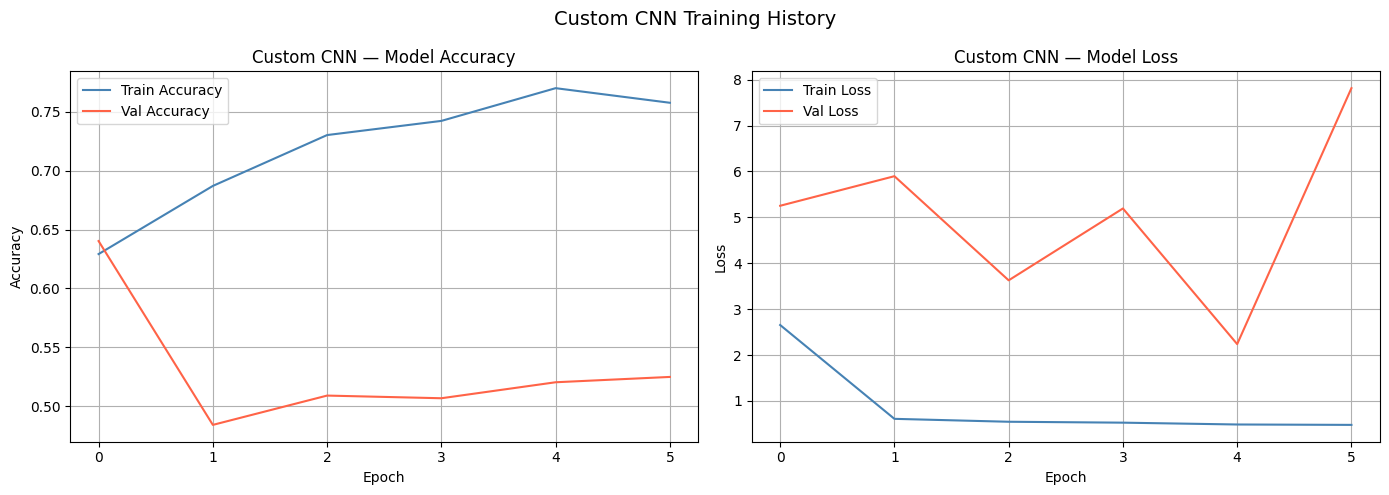

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
axes[0].set_title('Custom CNN — Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[1].set_title('Custom CNN — Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Custom CNN Training History', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Aerial Object Classification & Detection/models/cnn_training_plot.png')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 355ms/step
              precision    recall  f1-score   support

        Bird       0.64      1.00      0.78       126
       Drone       1.00      0.26      0.41        94

    accuracy                           0.68       220
   macro avg       0.82      0.63      0.59       220
weighted avg       0.80      0.68      0.62       220



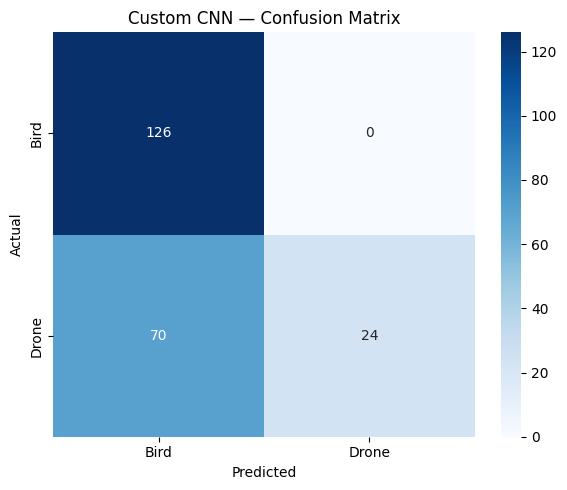

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_gen.reset()
preds       = cnn_model.predict(test_gen, verbose=1)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_gen.classes

print(classification_report(true_labels, pred_labels,
                            target_names=['Bird', 'Drone']))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bird', 'Drone'],
            yticklabels=['Bird', 'Drone'])
plt.title('Custom CNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Aerial Object Classification & Detection/models/cnn_confusion_matrix.png')
plt.show()

## Final Results & Model Comparison

In [10]:
test_loss, test_acc, test_prec, test_rec = cnn_model.evaluate(test_gen, verbose=0)
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-7)

print('=' * 40)
print(" CUSTOM CNN — FINAL RESULTS")
print('=' * 40)
print(f'Test Accuracy  : {test_acc*100:.2f}%')
print(f'Test Precision : {test_prec*100:.2f}%')
print(f'Test Recall    : {test_rec*100:.2f}%')
print(f'F1 Score       : {f1*100:.2f}%')
print(f'Test Loss      : {test_loss:.4f}')
print('=' * 40)
print()

 CUSTOM CNN — FINAL RESULTS
Test Accuracy  : 68.18%
Test Precision : 100.00%
Test Recall    : 25.53%
F1 Score       : 40.68%
Test Loss      : 4.4110

